In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [14]:
X = data.data
y = data.target
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.2,random_state=45)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score,mean_squared_error
print("R2 Score: ",r2_score(y_test,y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))


R2 Score:  0.40047774213856946
RMSE:  60.33037356647011


In [15]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=0.0001)
R.fit(X_train,y_train)
y_pred1 = R.predict(X_test)
print("R2 Score: ",r2_score(y_test,y_pred1))
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 Score:  0.40204840891646754
RMSE:  60.251293050680346


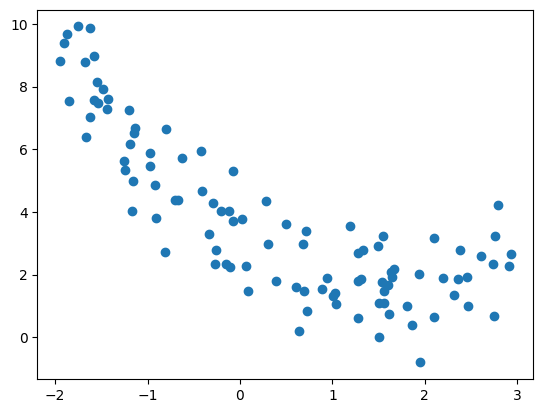

In [16]:
m = 100
x1 = 5 * np.random.rand(m,1) - 2
x2 = 0.7 * x1**2 - 2*x1 + 3 +np.random.randn(m,1)

plt.scatter(x1,x2)
plt.show()

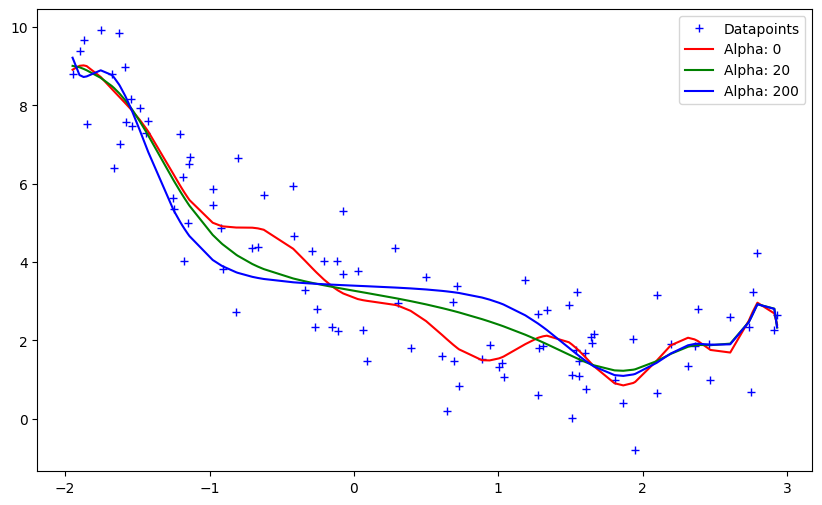

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1,x2,alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge',Ridge(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)

alphas = [0,20,200]
cs = ['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label = 'Datapoints')

for alpha ,c in zip(alphas,cs):
    preds = get_preds_ridge(x1,x2,alpha)
    plt.plot(sorted(x1[:,0]), preds[np.argsort(x1[: , 0])],c,label ='Alpha: {}'.format(alpha))

plt.legend()
plt.show()